In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from scikeras.wrappers import KerasRegressor
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [3]:
data_path = "analysistrue1.csv"
data = pd.read_csv(data_path)

In [4]:
data.head()

,country,year,location,yield,anthesisDate,Asi,plant_height,ear_position,stem_lodging,Epp,Ear_rot,region,total_precipitation,average_temperature,log_yield
0,Zimbabwe,2021,Chiredzi,3.336976,76,4,210.00,0.600000,3.125000,0.500000,9.375000,Region 4,109.2,26.166667,1.205065
1,Zimbabwe,2021,Chiredzi,2.745098,78,1,200.51,0.568251,14.285714,1.428571,10.000000,Region 4,109.2,26.166667,1.009817
2,Zimbabwe,2021,Chiredzi,3.876555,77,0,215.93,0.579540,0.000000,0.676471,2.173913,Region 4,109.2,26.166667,1.354947
3,Zimbabwe,2021,Chiredzi,3.269321,76,0,217.03,0.677234,3.125000,0.843750,3.703704,Region 4,109.2,26.166667,1.184582
4,Zimbabwe,2021,Chiredzi,3.514858,72,2,193.87,0.535462,0.000000,0.794118,0.000000,Region 4,109.2,26.166667,1.256999


In [5]:
data = data.drop(columns=['log_yield'])

In [6]:
data.isnull().sum()

country                0
year                   0
location               0
yield                  0
anthesisDate           0
Asi                    0
plant_height           0
ear_position           0
stem_lodging           0
Epp                    0
Ear_rot                0
region                 0
total_precipitation    0
average_temperature    0
dtype: int64

In [7]:
data = data.dropna()

In [9]:
new_order = [
    'year',
    'country',  
    'location', 
    'region',
    "anthesisDate",
    "Asi",
    "plant_height",
    "ear_position",
    "stem_lodging",
    "Epp",
    "Ear_rot",
    'average_temperature', 
    'total_precipitation',
    'yield' 
]

# Reordering the columns
data = data[new_order]

data.head()

,year,country,location,region,anthesisDate,Asi,plant_height,ear_position,stem_lodging,Epp,Ear_rot,average_temperature,total_precipitation,yield
0,2021,Zimbabwe,Chiredzi,Region 4,76,4,210.00,0.600000,3.125000,0.500000,9.375000,26.166667,109.2,3.336976
1,2021,Zimbabwe,Chiredzi,Region 4,78,1,200.51,0.568251,14.285714,1.428571,10.000000,26.166667,109.2,2.745098
2,2021,Zimbabwe,Chiredzi,Region 4,77,0,215.93,0.579540,0.000000,0.676471,2.173913,26.166667,109.2,3.876555
3,2021,Zimbabwe,Chiredzi,Region 4,76,0,217.03,0.677234,3.125000,0.843750,3.703704,26.166667,109.2,3.269321
4,2021,Zimbabwe,Chiredzi,Region 4,72,2,193.87,0.535462,0.000000,0.794118,0.000000,26.166667,109.2,3.514858


In [10]:
selected_columns = [
    "anthesisDate",
    "Asi",
    "plant_height",
    "ear_position",
    "stem_lodging",
    "Epp",
    "Ear_rot",
    'average_temperature', 
    'total_precipitation',
    'yield' 
]

data[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
anthesisDate,9936.0,71.221115,8.685880,40.000000,66.000000,71.000000,75.000000,101.000000
Asi,9936.0,1.541264,2.353404,-27.000000,0.000000,1.000000,2.000000,27.000000
plant_height,9936.0,217.977190,64.689355,1.760000,195.000000,227.350000,255.000000,2755.000000
ear_position,9936.0,0.528526,0.171791,0.053333,0.475000,0.510000,0.555556,2.642857
stem_lodging,9936.0,4.797360,10.079889,0.000000,0.000000,0.000000,5.555556,103.030303
Epp,9936.0,0.892455,0.283677,0.028571,0.764706,0.916667,1.031502,12.000000
Ear_rot,9936.0,9.711454,13.803152,0.000000,2.325581,6.250000,12.500000,300.000000
average_temperature,9936.0,21.558329,2.880547,15.916667,19.750000,20.833333,24.152794,27.083333
total_precipitation,9936.0,248.951153,161.511502,31.820000,111.350000,229.600000,315.200000,673.200000
yield,9936.0,5.480752,3.162968,0.000000,2.839553,4.954431,7.971837,14.667701


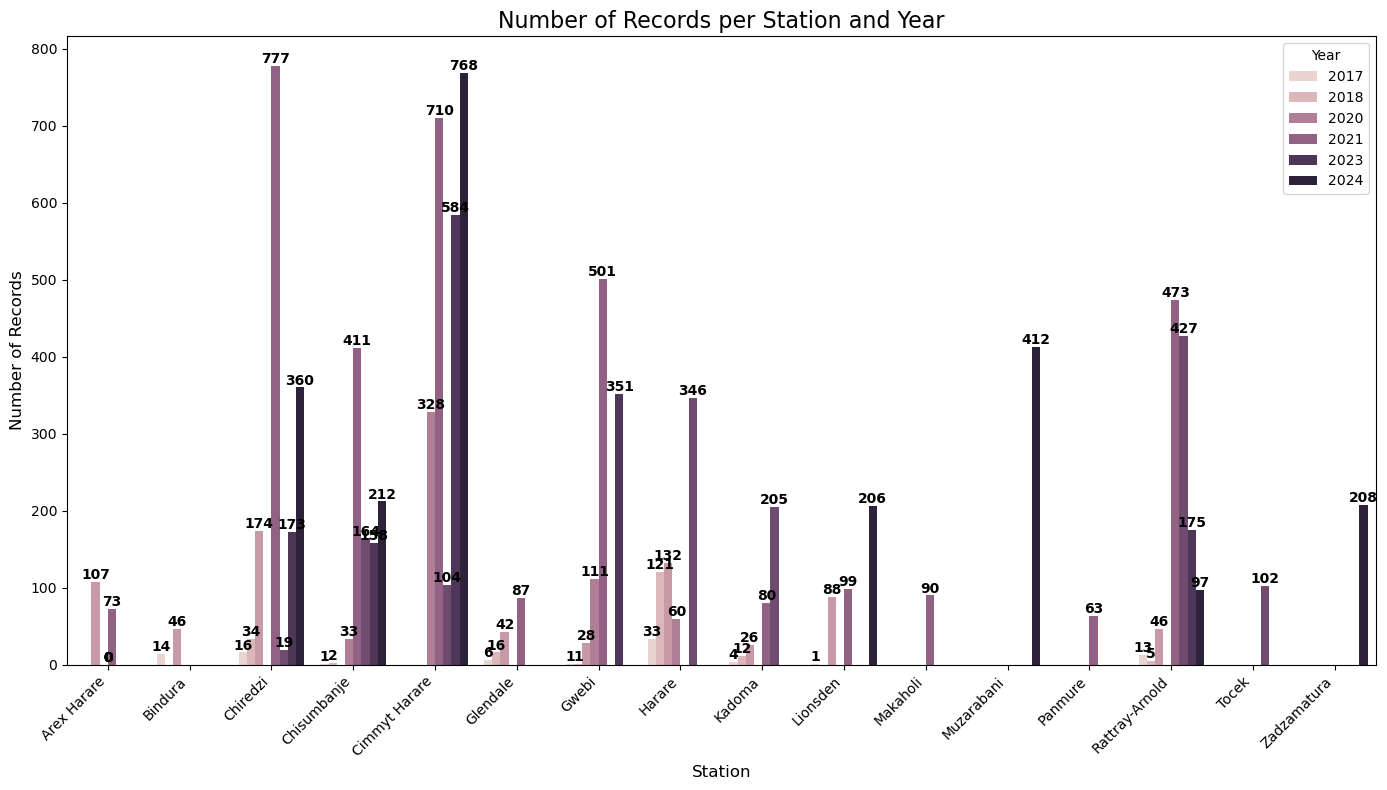

In [11]:


# Grouping the data
district_sector_counts = data.groupby(["location", "year"]).size().reset_index(name="record_count")

# Plotting the bar plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=district_sector_counts,
    x="location",
    y="record_count",
    hue="year",
    ci=None
)

# Adding the count on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',  # Display the count
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position of the count
        ha='center', va='center', fontsize=10, color='black', fontweight='bold', xytext=(0, 5), textcoords='offset points'
    )

plt.title("Number of Records per Station and Year", fontsize=16)
plt.xlabel("Station", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
sector_counts = data['location'].value_counts()
sector_percentage = (sector_counts / len(data)) * 100
print("Station Contribution towards Total Records (%):")
print(sector_percentage)

# ii. Calculate the average yield per sector
average_yield_per_sector = data.groupby('location')['yield'].mean()
print("\nAverage Yield per Sector:")
print(average_yield_per_sector)

Station Contribution towards Total Records (%):
location
Cimmyt Harare     25.100644
Chiredzi          15.630032
Rattray-Arnold    12.439614
Gwebi              9.993961
Chisumbanje        9.873188
Harare             6.964573
Muzarabani         4.146538
Lionsden           3.965378
Kadoma             3.291063
Zadzamatura        2.093398
Arex Harare        1.811594
Glendale           1.519726
Tocek              1.026570
Makaholi           0.905797
Panmure            0.634058
Bindura            0.603865
Name: count, dtype: float64

Average Yield per Sector:
location
Arex Harare       4.622075
Bindura           6.804167
Chiredzi          3.502880
Chisumbanje       3.088428
Cimmyt Harare     7.143058
Glendale          8.227045
Gwebi             5.313569
Harare            6.960417
Kadoma            4.266566
Lionsden          6.091609
Makaholi          5.744810
Muzarabani        3.251165
Panmure           0.486493
Rattray-Arnold    6.227572
Tocek             9.087891
Zadzamatura       6.202338

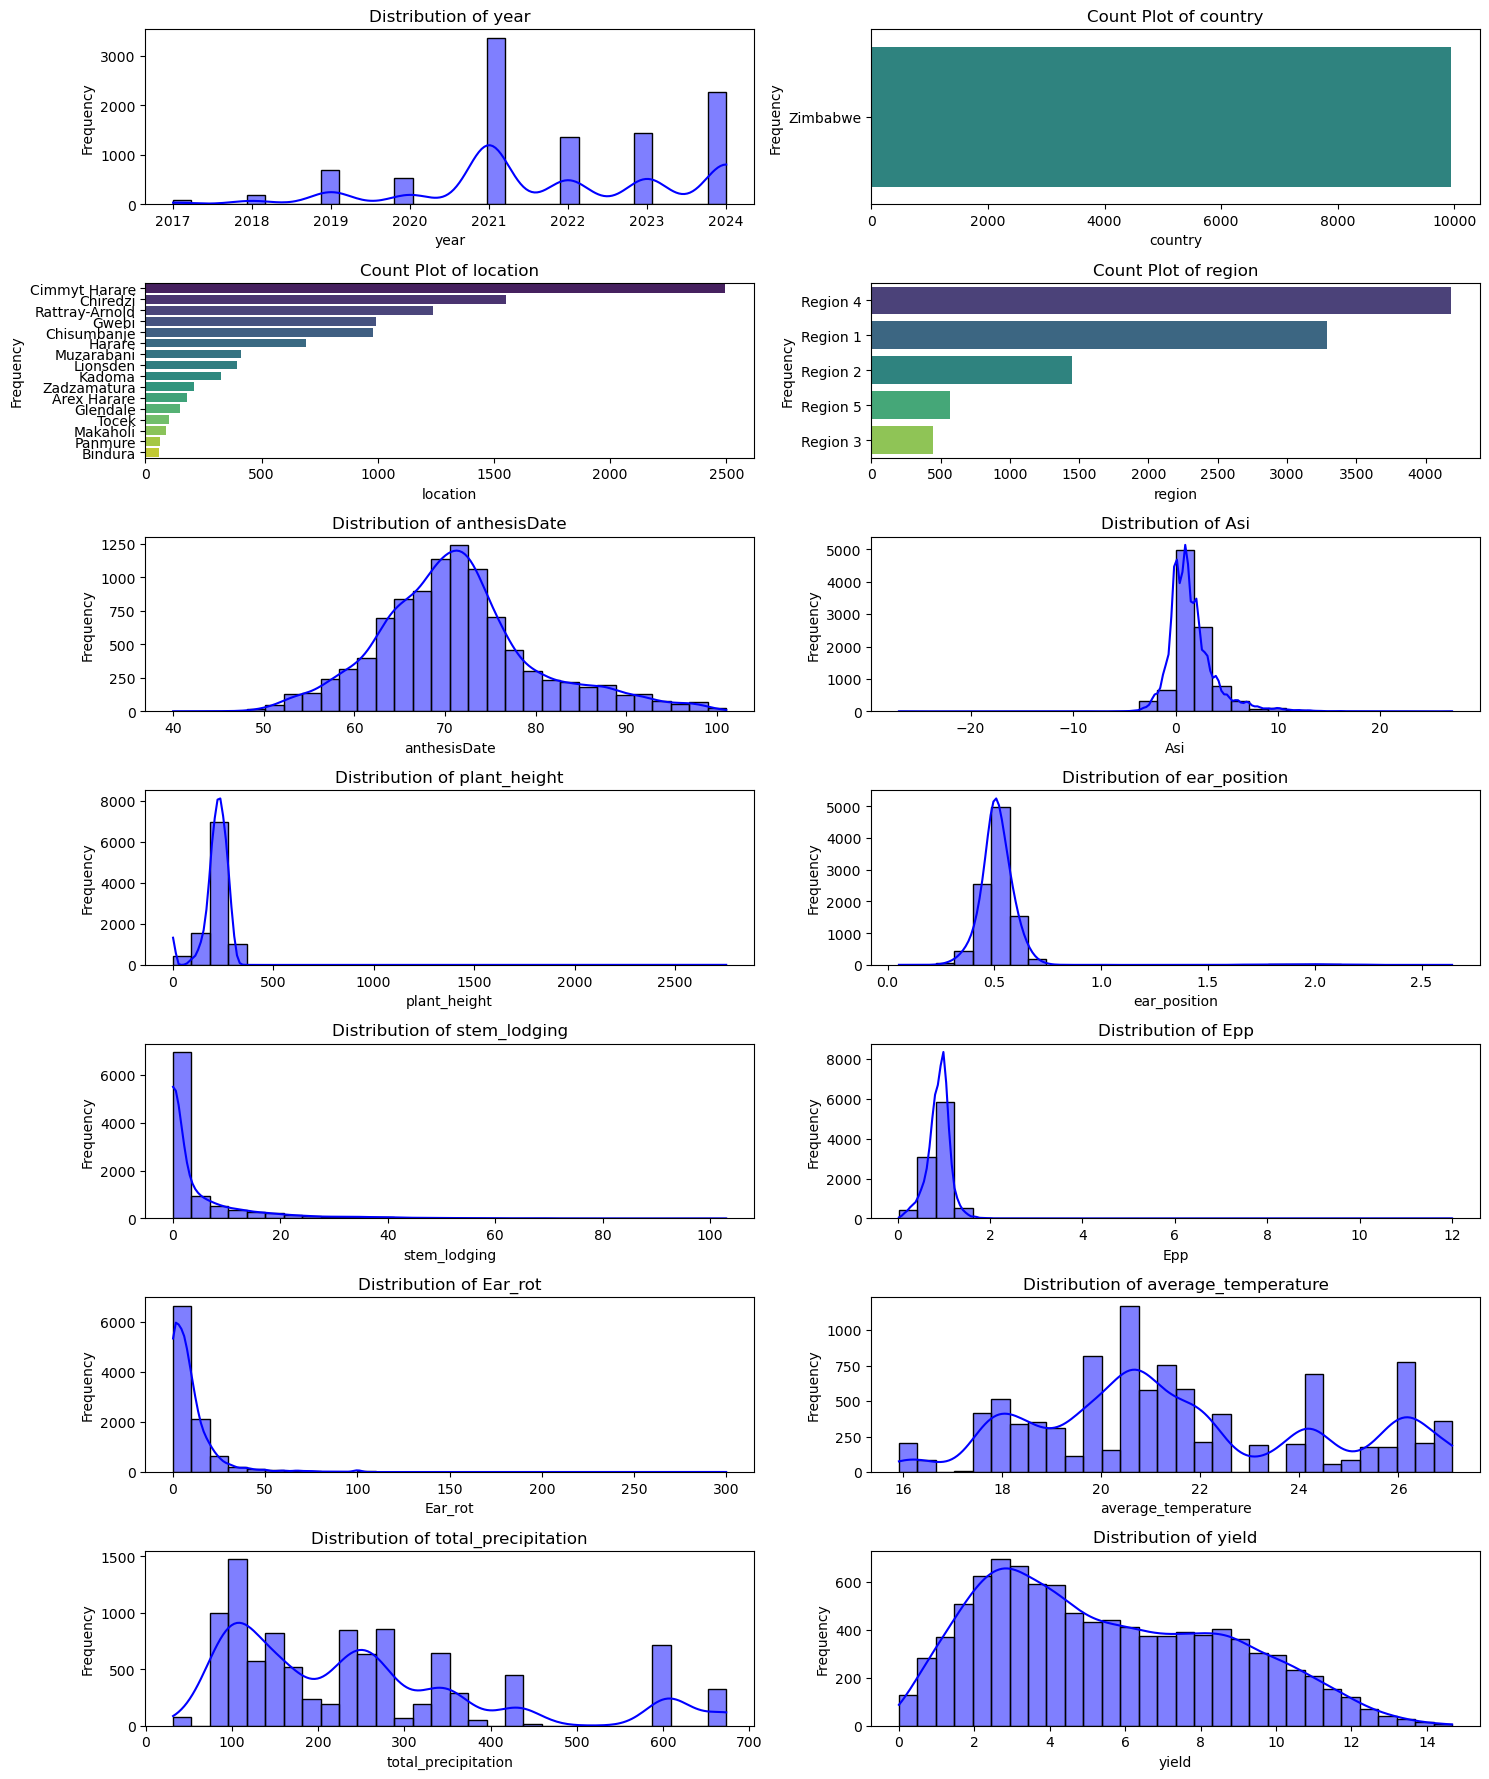

In [13]:
columns_to_plot = [
    'year',
    'country',  
    'location', 
    'region',
    "anthesisDate",
    "Asi",
    "plant_height",
    "ear_position",
    "stem_lodging",
    "Epp",
    "Ear_rot",
    'average_temperature', 
    'total_precipitation',
    'yield'
]

plt.figure(figsize=(15, 20))

for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot) // 2 + 1, 2, i)
    if data[column].dtype in ['float64', 'int64']:
        sns.histplot(data[column], kde=True, bins=30, color='blue')
        plt.title(f'Distribution of {column}')
    else:
        sns.countplot(y=data[column], palette='viridis', order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

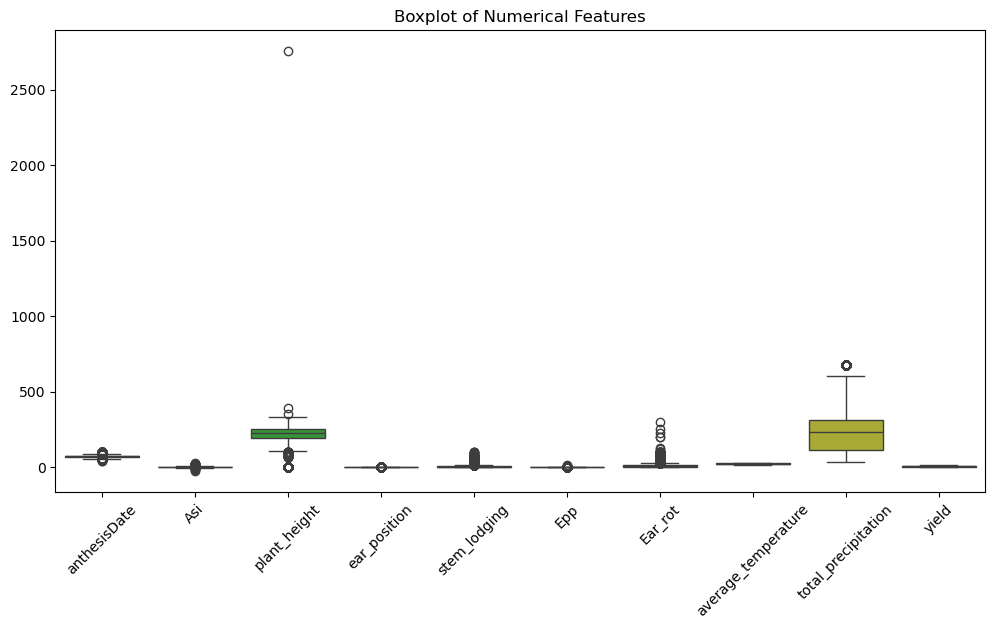

In [14]:
# Boxplot for numerical features
numerical_cols = ["anthesisDate",
    "Asi",
    "plant_height",
    "ear_position",
    "stem_lodging",
    "Epp",
    "Ear_rot",
    'average_temperature', 
    'total_precipitation',
    'yield']
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

In [15]:
def handle_outliers(data, columns, threshold=1.5):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])


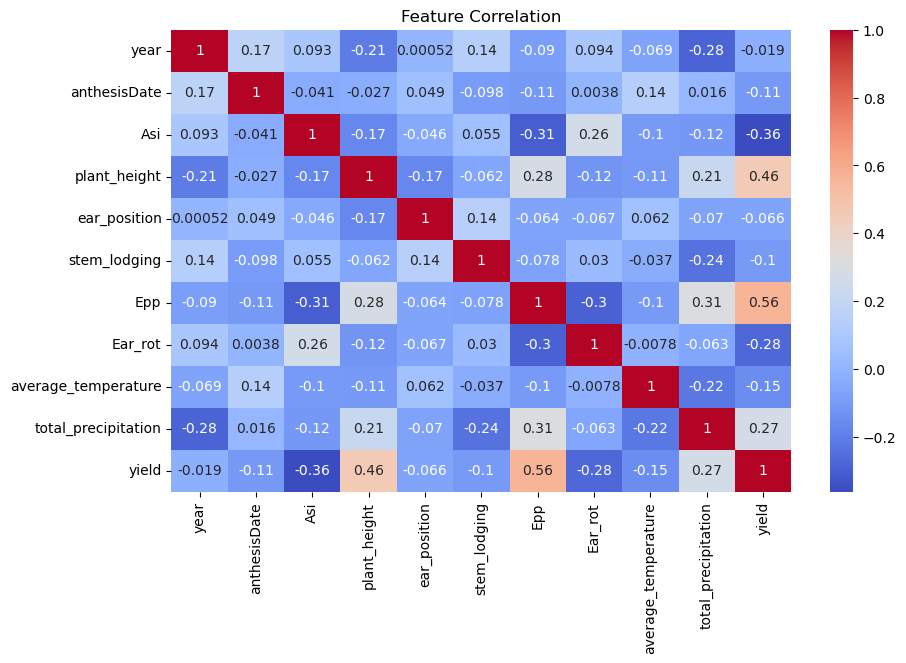

In [16]:
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [17]:
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
# numerical_columns = [col for col in numerical_columns if col != 'year']

handle_outliers(data, numerical_columns)

scaler = MinMaxScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [18]:
# Encode Categorical Columns
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

X = data.drop(columns=['yield'])
y = data['yield']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [20]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [21]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [22]:
ann_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

ann_model.compile(optimizer='adam', loss='mean_squared_error')
ann_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
ann_preds = ann_model.predict(X_test).flatten()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [23]:
def evaluate_model(true, preds, model_name):
    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    r2 = r2_score(true, preds)
    print(f"\n{model_name} Evaluation:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

In [24]:
evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest")
evaluate_model(y_test, xgb_preds, "XGBoost")
evaluate_model(y_test, ann_preds, "ANN")


Linear Regression Evaluation:
Mean Squared Error: 0.0142
Mean Absolute Error: 0.0936
R2 Score: 0.6865

Random Forest Evaluation:
Mean Squared Error: 0.0089
Mean Absolute Error: 0.0678
R2 Score: 0.8044

XGBoost Evaluation:
Mean Squared Error: 0.0082
Mean Absolute Error: 0.0661
R2 Score: 0.8186

ANN Evaluation:
Mean Squared Error: 0.0081
Mean Absolute Error: 0.0658
R2 Score: 0.8200


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━

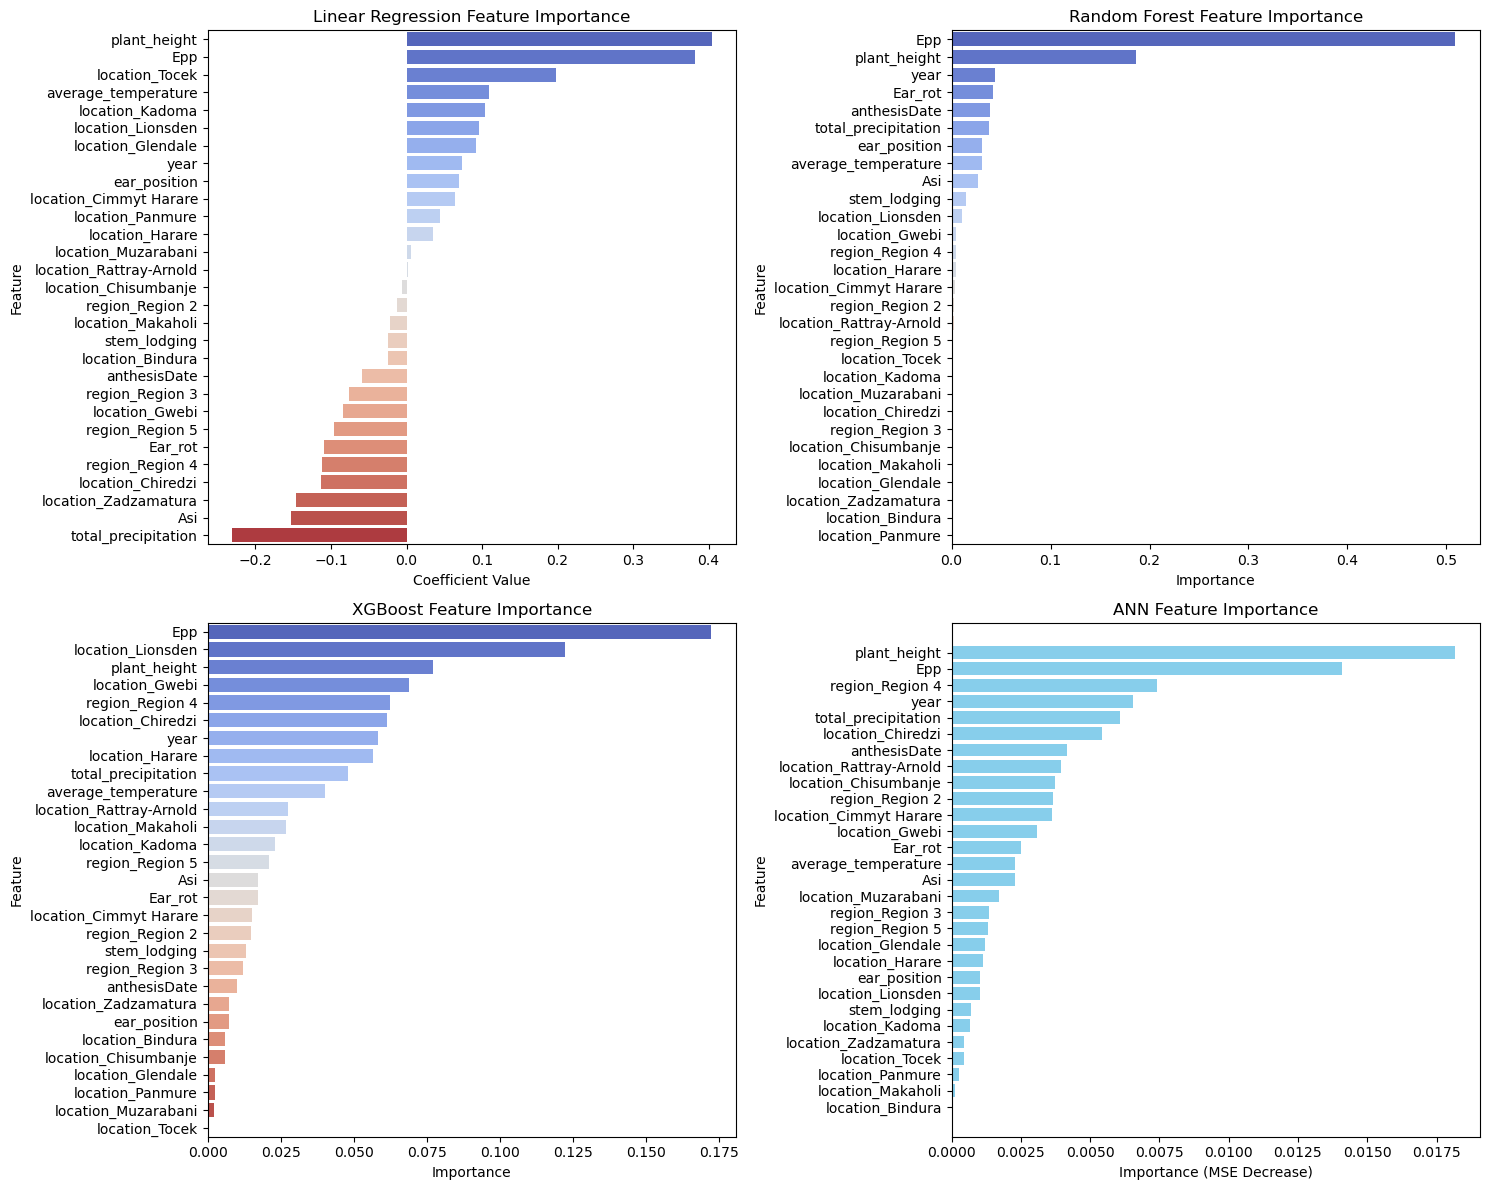

In [25]:
# Function to plot feature importance
def plot_feature_importance(model, X_train, model_name, ax, plot_type='barh'):
    if model_name == 'Linear Regression':
        importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.coef_
        }).sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance, ax=ax, palette='coolwarm')
        ax.set_xlabel('Coefficient Value')
    elif model_name == 'Random Forest':
        importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance, ax=ax, palette='coolwarm')
        ax.set_xlabel('Importance')
    elif model_name == 'XGBoost':
        importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance, ax=ax, palette='coolwarm')
        ax.set_xlabel('Importance')
    elif model_name == 'ANN':
        ann_preds = model.predict(X_test).flatten()
        baseline_mse = mean_squared_error(y_test, ann_preds)
        
        feature_importances = []
        for col in X_test.columns:
            X_test_shuffled = X_test.copy()
            X_test_shuffled[col] = np.random.permutation(X_test_shuffled[col])
            shuffled_preds = model.predict(X_test_shuffled).flatten()
            shuffled_mse = mean_squared_error(y_test, shuffled_preds)
            importance = shuffled_mse - baseline_mse
            feature_importances.append((col, importance))
        
        feature_importances.sort(key=lambda x: x[1], reverse=True)
        ann_features = [f[0] for f in feature_importances]
        ann_importances = [f[1] for f in feature_importances]
        
        ax.barh(ann_features, ann_importances, color='skyblue')
        ax.set_xlabel('Importance (MSE Decrease)')
        ax.invert_yaxis()  # To display the most important feature at the top

    ax.set_title(f"{model_name} Feature Importance")
    ax.set_ylabel('Feature')

# Create subplots for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot feature importance for each model
models = [(lr_model, 'Linear Regression'), 
          (rf_model, 'Random Forest'), 
          (xgb_model, 'XGBoost'), 
          (ann_model, 'ANN')]

for ax, (model, name) in zip(axes.flatten(), models):
    plot_feature_importance(model, X_train, name, ax)

plt.tight_layout()
plt.show()


In [26]:
# Define the parameter grids
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the models
xgb_model = XGBRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)

# Perform GridSearchCV for XGBRegressor
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, 
                               cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Perform GridSearchCV for RandomForestRegressor
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, 
                              cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Best parameters and scores
print("Best parameters for XGBRegressor:", xgb_grid_search.best_params_)
print("Best score for XGBRegressor:", -xgb_grid_search.best_score_)  # Convert negative MSE to positive

print("Best parameters for RandomForestRegressor:", rf_grid_search.best_params_)
print("Best score for RandomForestRegressor:", -rf_grid_search.best_score_)  # Convert negative MSE to positive

# Use the best models to make predictions
xgb_best_model = xgb_grid_search.best_estimator_
rf_best_model = rf_grid_search.best_estimator_

xgb_preds = xgb_best_model.predict(X_test)
rf_preds = rf_best_model.predict(X_test)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters for XGBRegressor: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best score for XGBRegressor: 0.008178940684015338
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best score for RandomForestRegressor: 0.008603488783367743


In [27]:
# Best parameters for XGBRegressor
xgb_best_model = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)

# Best parameters for RandomForestRegressor
rf_best_model = RandomForestRegressor(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

# Train the models with the best parameters
xgb_best_model.fit(X_train, y_train)
rf_best_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_best_model.predict(X_test)
rf_preds = rf_best_model.predict(X_test)

# Calculate R² and RMSE for XGBRegressor
xgb_r2 = r2_score(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

# Calculate R² and RMSE for RandomForestRegressor
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Print results
print("XGBRegressor:")
print(f"R²: {xgb_r2:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")

print("\nRandomForestRegressor:")
print(f"R²: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")


XGBRegressor:
R²: 0.8284
RMSE: 0.0881

RandomForestRegressor:
R²: 0.8071
RMSE: 0.0934


In [63]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import numpy as np

# Define a function to create the model for KerasRegressor
def create_ann_model(optimizer='adam', neurons_1=64, neurons_2=32):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(neurons_1, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(neurons_2, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Wrap the model using KerasRegressor
ann_model = KerasRegressor(model=create_ann_model, verbose=0)

# Define the parameter grid
param_grid = {
    'model__optimizer': ['adam', 'sgd'],
    'model__neurons_1': [32, 64, 128],
    'model__neurons_2': [16, 32, 64],
    'batch_size': [16, 32, 64],
    'epochs': [50, 100]
}

# Perform GridSearchCV
grid = GridSearchCV(estimator=ann_model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)
grid_result = grid.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_result.best_params_)
print("Best Score (Negative MSE):", grid_result.best_score_)

# Test the new ANN model with optimal parameters
best_model = grid_result.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE:", mse)
print("Test R2 Score:", r2)